In [ ]:
# Install TensorFlow Datasets (if not already available)
!pip install tensorflow-datasets

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.decomposition import PCA
import tensorflow as tf
import tensorflow_datasets as tfds


In [ ]:
# Load cats_vs_dogs dataset
dataset, info = tfds.load('cats_vs_dogs', with_info=True, as_supervised=True)

# Convert dataset to NumPy arrays (only first 5000 samples for speed)
X, y = [], []
for i, (image, label) in enumerate(tfds.as_numpy(dataset['train'])):
    if i >= 5000:  # Limit dataset size
        break
    img = tf.image.resize(image, (32,32)).numpy() / 255.0  # Resize to 32x32
    X.append(img.flatten())  # Flatten image
    y.append(label)

X = np.array(X)
y = np.array(y)

print("Dataset shape:", X.shape, y.shape)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.LBU979_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
Dataset shape: (5000, 3072) (5000,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42

)


In [ ]:
from sklearn.decomposition import PCA

# Reduce 3072 features → 100
pca = PCA(n_components=100)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("PCA reduced shape:", X_train_pca.shape, X_test_pca.shape)


PCA reduced shape: (4000, 100) (1000, 100)


In [ ]:
from sklearn.svm import SVC

svm_model = SVC(kernel='linear')   # define model
svm_model.fit(X_train_pca, y_train)  # train model


SVC(kernel='linear')

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = svm_model.predict(X_test_pca)

print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))


✅ Accuracy: 0.566

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.58      0.58       507
           1       0.56      0.55      0.56       493

    accuracy                           0.57      1000
   macro avg       0.57      0.57      0.57      1000
weighted avg       0.57      0.57      0.57      1000



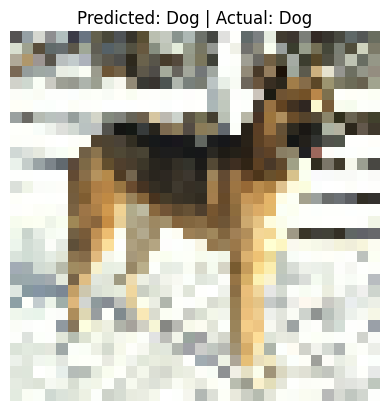

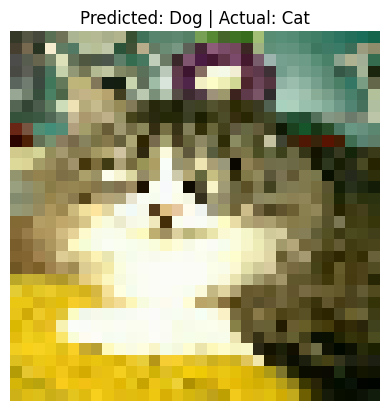

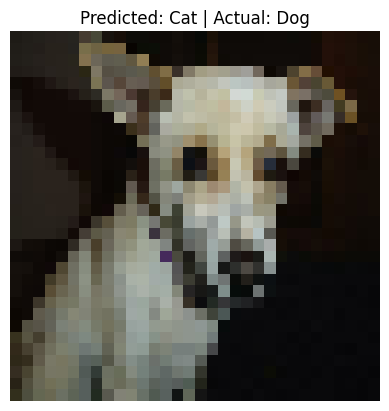

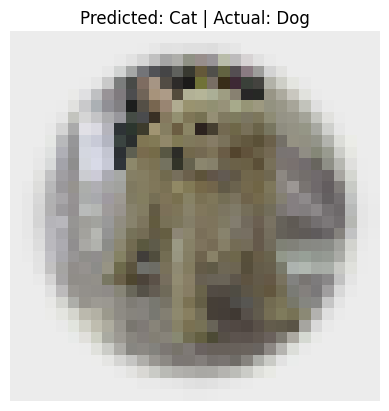

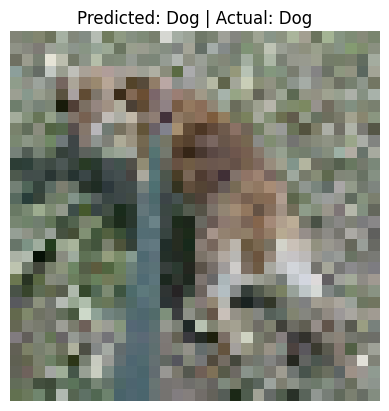

In [ ]:
import matplotlib.pyplot as plt

# Show 5 random test samples
for i in range(5):
    idx = np.random.randint(0, len(X_test))
    img = X_test[idx].reshape(32,32,3)   # reshape back to image
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Predicted: {'Dog' if y_pred[idx]==1 else 'Cat'} | Actual: {'Dog' if y_test[idx]==1 else 'Cat'}")
    plt.show()


In [ ]:
import joblib

# Save model and PCA
joblib.dump(svm_model, "svm_cats_vs_dogs.pkl")
joblib.dump(pca, "pca_cats_vs_dogs.pkl")

print("✅ Model and PCA saved!")


✅ Model and PCA saved!


In [ ]:
# Load model and PCA again
svm_loaded = joblib.load("svm_cats_vs_dogs.pkl")
pca_loaded = joblib.load("pca_cats_vs_dogs.pkl")

# Transform and test on a few images
sample = X_test[:10]
sample_pca = pca_loaded.transform(sample)
preds = svm_loaded.predict(sample_pca)

print("Sample predictions:", preds)
print("Actual labels:", y_test[:10])


Sample predictions: [0 1 0 1 0 1 1 1 0 1]
Actual labels: [1 1 0 0 1 1 1 0 1 0]
